## Import Libraries

In [96]:
import pandas as pd
import numpy as np
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)

## Load and Basic Cleaning

In [97]:
df = pd.read_csv('beijing_dataset.csv')
pd.set_option('display.max_columns', None)
df.head()

,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir
0,1,2010,1,1,0,NaN,-21,-11.0,1021.0,NW,1.79,0,0
1,2,2010,1,1,1,NaN,-21,-12.0,1020.0,NW,4.92,0,0
2,3,2010,1,1,2,NaN,-21,-11.0,1019.0,NW,6.71,0,0
3,4,2010,1,1,3,NaN,-21,-14.0,1019.0,NW,9.84,0,0
4,5,2010,1,1,4,NaN,-20,-12.0,1018.0,NW,12.97,0,0


In [98]:
df.drop(columns='No', inplace=True)

In [99]:
df = df.sort_values(['year', 'month', 'day', 'hour']).reset_index(drop=True)


In [100]:
df.shape

(43824, 12)

In [101]:
print(f"Year range {df['year'].min()} - {df['year'].max()} ")
print(f"Month range {df['month'].min()} - {df['month'].max()}")
print(f"Day range {df['day'].min()} - {df['day'].max()} ")
print(f"Hour range {df['hour'].min()} - {df['hour'].max()} ")

Year range 2010 - 2014 
Month range 1 - 12
Day range 1 - 31 
Hour range 0 - 23 


## Exploratory Data Analysis

In [102]:
df.isnull().sum()

year        0
month       0
day         0
hour        0
pm2.5    2067
DEWP        0
TEMP        0
PRES        0
cbwd        0
Iws         0
Is          0
Ir          0
dtype: int64

In [103]:
df['pm2.5'] = df['pm2.5'].interpolate(method='linear', limit_direction='both')

### 3.1 PM2.5 Distribution

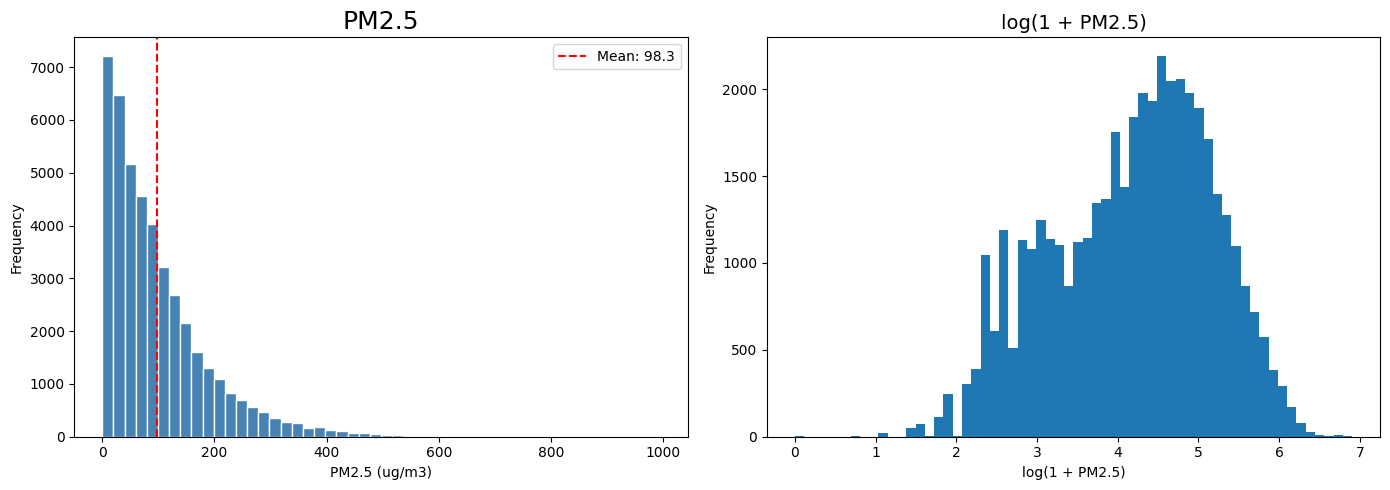

Skewness (raw): 0        129.0
1        129.0
2        129.0
3        129.0
4        129.0
         ...  
43819      8.0
43820     10.0
43821     10.0
43822      8.0
43823     12.0
Name: pm2.5, Length: 43824, dtype: float64


In [104]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['pm2.5'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('PM2.5', fontsize=18)
axes[0].set_xlabel('PM2.5 (ug/m3)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['pm2.5'].mean(), color='red', linestyle='--', label=f"Mean: {df['pm2.5'].mean():.1f}")
axes[0].legend()

axes[1].hist(np.log1p(df['pm2.5']), bins=60)
axes[1].set_title('log(1 + PM2.5)', fontsize=14)
axes[1].set_xlabel('log(1 + PM2.5)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f"Skewness (raw): {df['pm2.5']}")

### 3.2 Correlation Heatmap

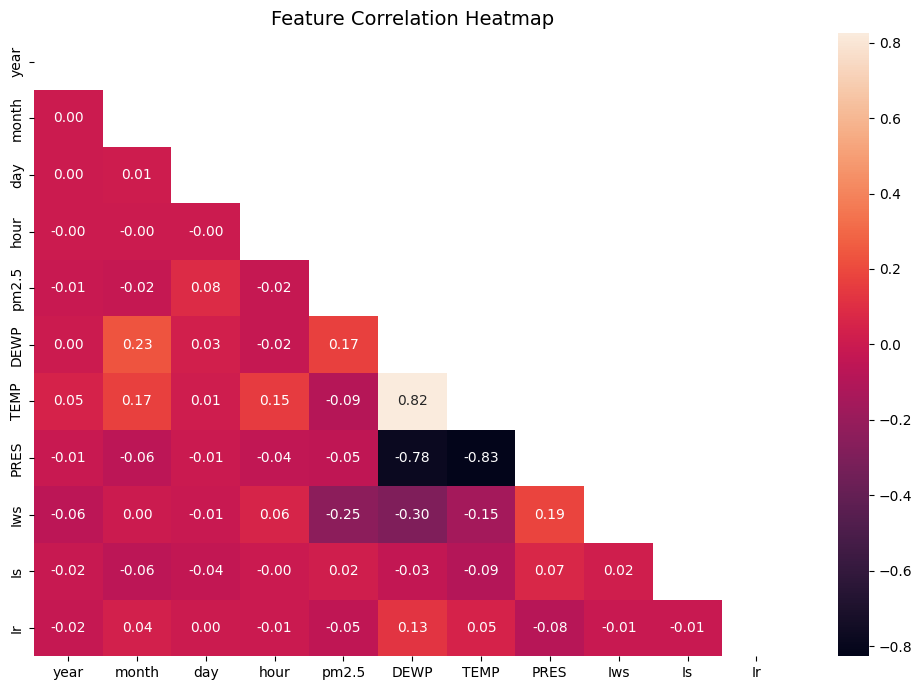

Top correlations with PM2.5
Iws      0.245688
DEWP     0.168500
TEMP     0.089358
day      0.083124
Ir       0.050247
PRES     0.048006
hour     0.023983
month    0.023578
Is       0.019300
year     0.009179


In [105]:
plt.figure(figsize=(10, 7))
corr = df.select_dtypes(include=['int64', 'float64']).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr,mask=mask ,annot=True, fmt='.2f')
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

print('Top correlations with PM2.5')
print(corr['pm2.5'].drop('pm2.5').abs().sort_values(ascending=False).to_string())


### 3.3 Temporal Patterns

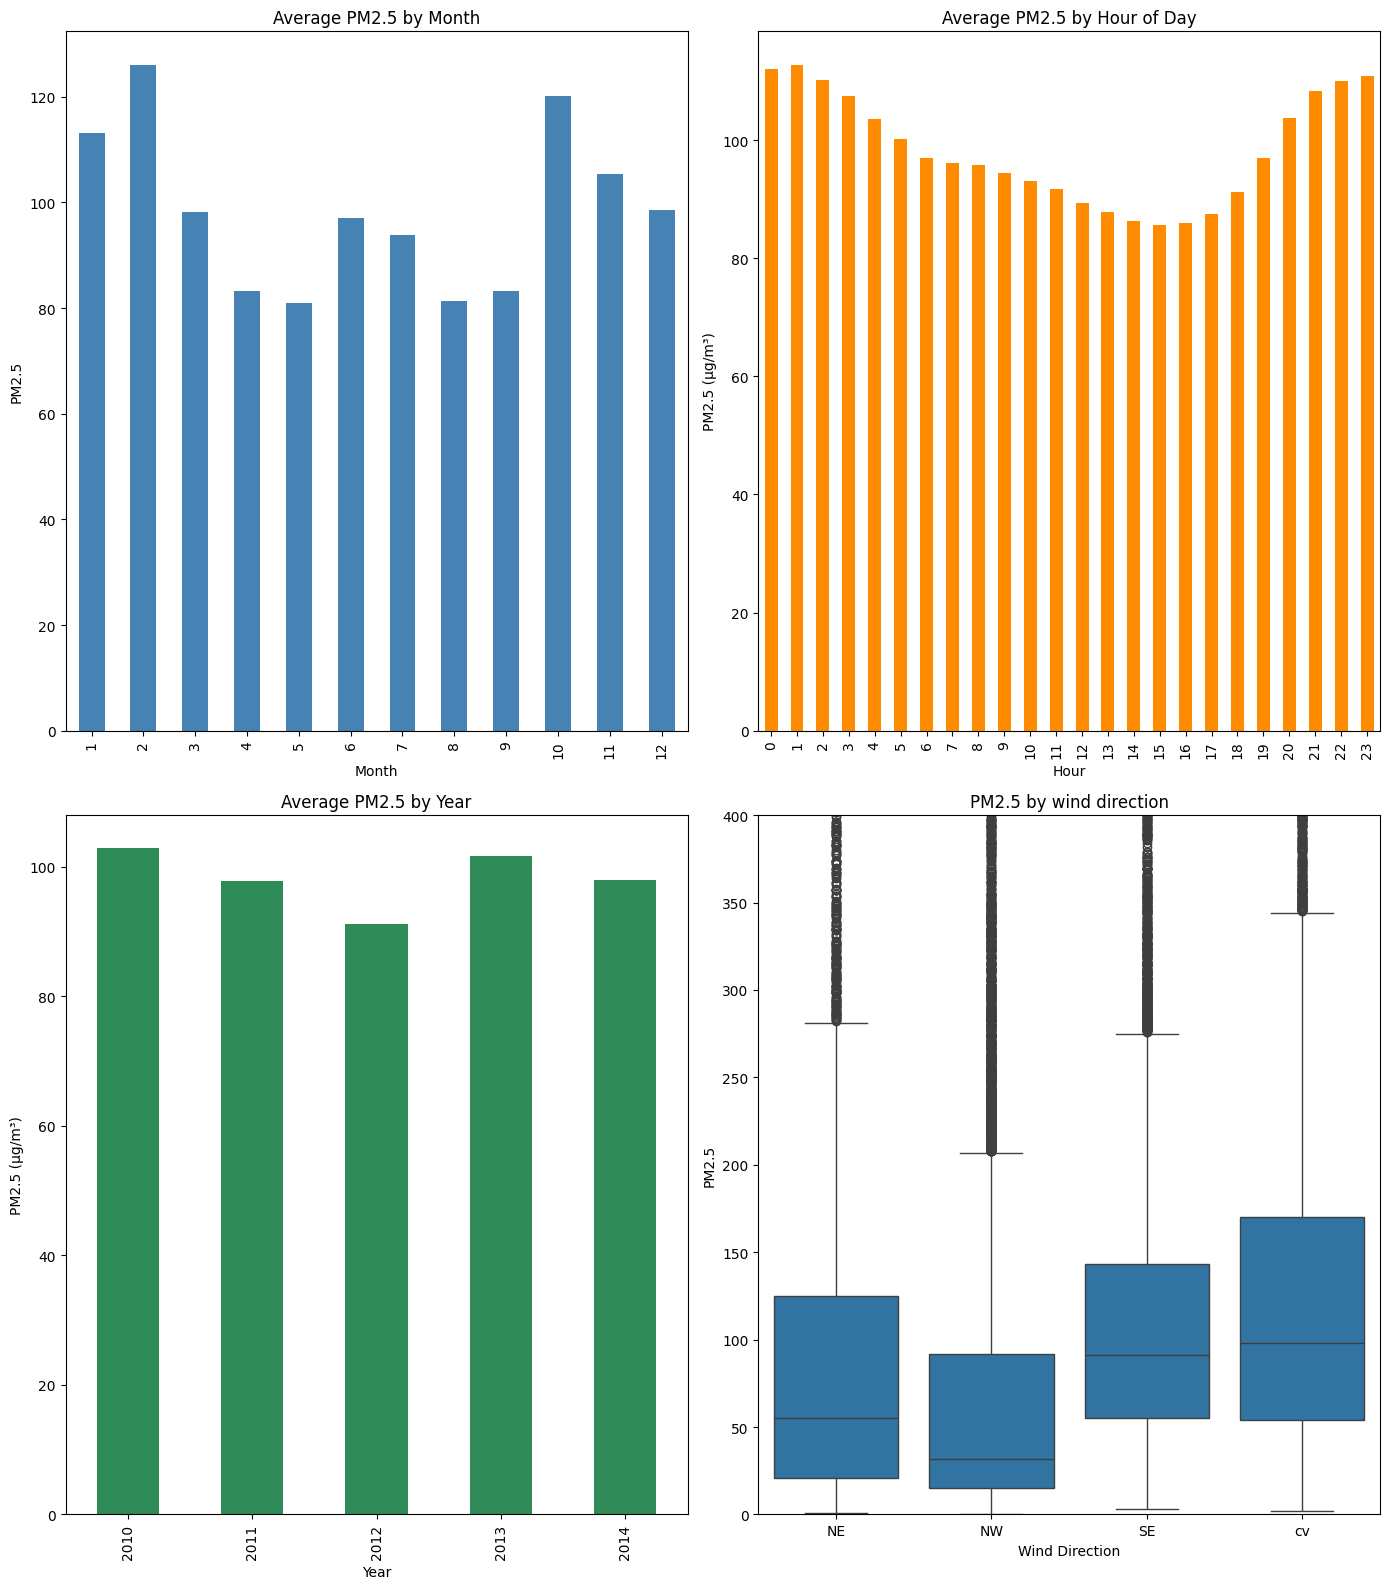

In [106]:
fig, axes = plt.subplots(2, 2, figsize=(14, 16))

# monthly pattern 
df.groupby('month')['pm2.5'].mean().plot(kind='bar', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Average PM2.5 by Month')
axes[0, 0].set_xlabel('Month')
axes[0, 0].set_ylabel('PM2.5')

# Hourly Pattern
df.groupby('hour')['pm2.5'].mean().plot(kind='bar', ax=axes[0,1], color='darkorange')
axes[0,1].set_title('Average PM2.5 by Hour of Day')
axes[0,1].set_xlabel('Hour')
axes[0,1].set_ylabel('PM2.5 (µg/m³)')

# Year-over-year
df.groupby('year')['pm2.5'].mean().plot(kind='bar', ax=axes[1,0], color='seagreen')
axes[1,0].set_title('Average PM2.5 by Year')
axes[1,0].set_xlabel('Year')
axes[1,0].set_ylabel('PM2.5 (µg/m³)')

# Wind direction
sns.boxplot(x=df['cbwd'], y=df['pm2.5'], ax=axes[1, 1], order=['NE', 'NW', 'SE', 'cv'])
axes[1, 1].set_title('PM2.5 by wind direction')
axes[1, 1].set_xlabel('Wind Direction')
axes[1, 1].set_ylabel('PM2.5')
axes[1, 1].set_ylim(0, 400)

plt.tight_layout()
plt.show()


### 3.4 Meteorological Feature Relationship

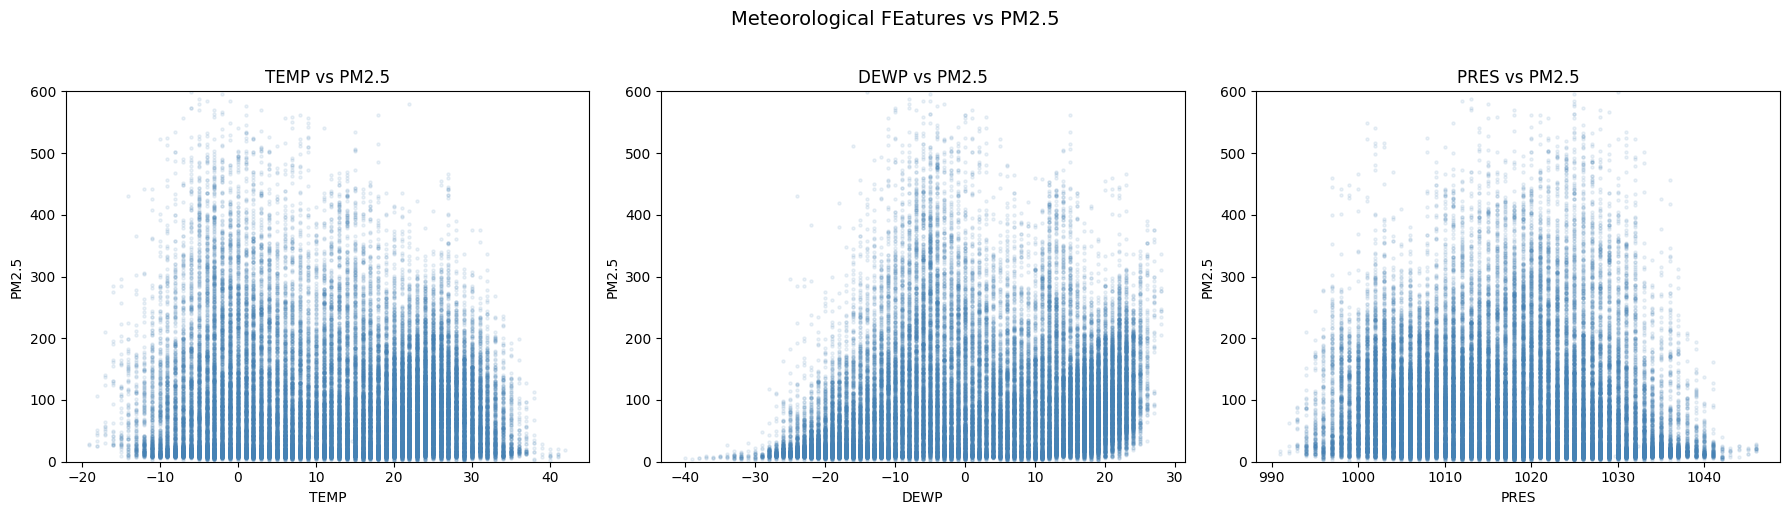

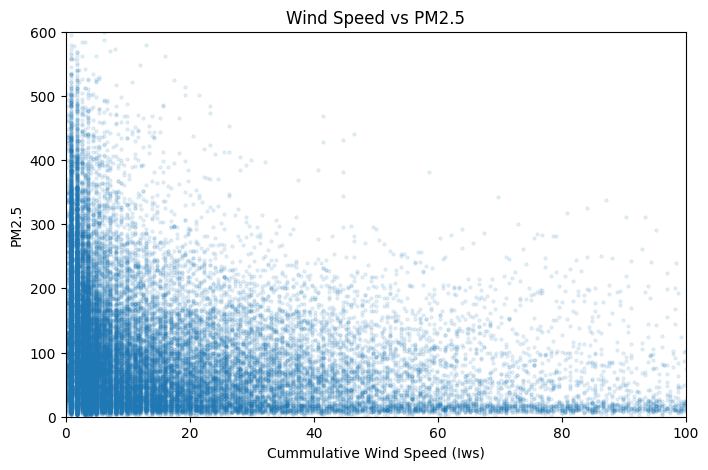

In [107]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, ['TEMP', 'DEWP', 'PRES']):
    ax.scatter(df[col], df['pm2.5'], alpha=0.1, s=5, color='steelblue')
    ax.set_xlabel(col)
    ax.set_ylabel('PM2.5')
    ax.set_title(f'{col} vs PM2.5')
    ax.set_ylim(0, 600)

plt.suptitle("Meteorological FEatures vs PM2.5", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(df['Iws'], df['pm2.5'], alpha=0.1, s=5)
plt.xlabel('Cummulative Wind Speed (Iws)')
plt.ylabel('PM2.5')
plt.title('Wind Speed vs PM2.5')
plt.ylim(0, 600)
plt.xlim(0, 100)
plt.show()

### 3.5 Temporal Autocorrelation

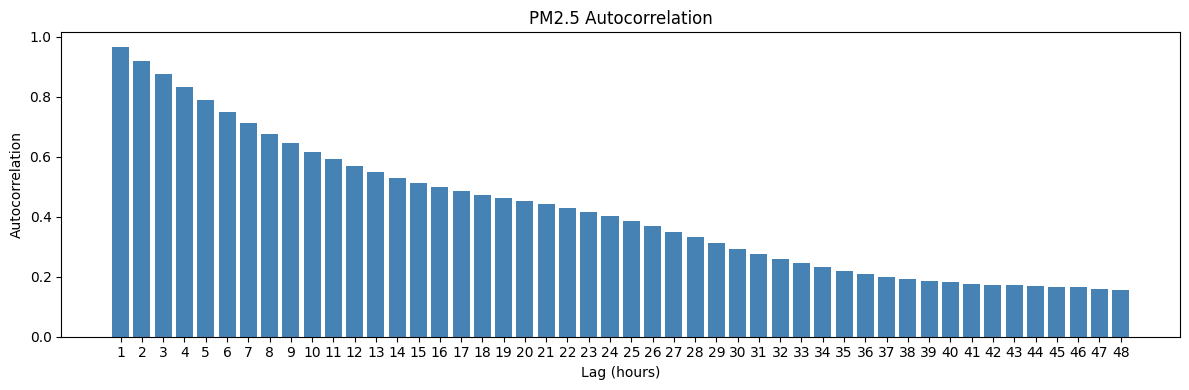

Autocorrelation at lag-1: 0.966
Autocorrelation at lag-2: 0.920
Autocorrelation at lag-24: 0.402


In [108]:
lags = range(1, 49)
autocorr = [df['pm2.5'].autocorr(lag=lag) for lag in lags]

plt.figure(figsize=(12, 4))
plt.bar(lags, autocorr, color='steelblue')
plt.axhline(0, color='black', linewidth=0.5)
plt.xlabel('Lag (hours)')
plt.ylabel('Autocorrelation')
plt.title('PM2.5 Autocorrelation')
plt.xticks(list(range(1, 49, 1)))
plt.tight_layout()
plt.show()

print(f"Autocorrelation at lag-1: {df['pm2.5'].autocorr(1):.3f}")
print(f"Autocorrelation at lag-2: {df['pm2.5'].autocorr(2):.3f}")
print(f"Autocorrelation at lag-24: {df['pm2.5'].autocorr(24):.3f}")

### 4. Feature Engineering

In [109]:
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

df.drop(columns=['hour', 'month'], inplace=True)

for lag in [1, 2, 3, 24]:
    df[f'pm25_lag{lag}'] = df['pm2.5'].shift(lag)

df['pm25_roll3'] = df['pm2.5'].shift(1).rolling(window=3).mean()
df['pm25_roll24'] = df['pm2.5'].shift(1).rolling(window=24).mean()

df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Dataset shape after feature engineering: {df.shape}")
print(f"New features: {[c for c in df.columns if 'lag' in c or 'roll' in c or 'sin' in c or 'cos' in c]}")

Dataset shape after feature engineering: (43800, 20)
New features: ['hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'pm25_lag1', 'pm25_lag2', 'pm25_lag3', 'pm25_lag24', 'pm25_roll3', 'pm25_roll24']


In [110]:
df

,year,day,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir,hour_sin,hour_cos,month_sin,month_cos,pm25_lag1,pm25_lag2,pm25_lag3,pm25_lag24,pm25_roll3,pm25_roll24
0,2010,2,129.0,-16,-4.0,1020.0,SE,1.79,0,0,0.000000,1.000000,5.000000e-01,0.866025,129.0,129.0,129.0,129.0,129.000000,129.000000
1,2010,2,148.0,-15,-4.0,1020.0,SE,2.68,0,0,0.258819,0.965926,5.000000e-01,0.866025,129.0,129.0,129.0,129.0,129.000000,129.000000
2,2010,2,159.0,-11,-5.0,1021.0,SE,3.57,0,0,0.500000,0.866025,5.000000e-01,0.866025,148.0,129.0,129.0,129.0,135.333333,129.791667
3,2010,2,181.0,-7,-5.0,1022.0,SE,5.36,1,0,0.707107,0.707107,5.000000e-01,0.866025,159.0,148.0,129.0,129.0,145.333333,131.041667
4,2010,2,138.0,-7,-5.0,1022.0,SE,6.25,2,0,0.866025,0.500000,5.000000e-01,0.866025,181.0,159.0,148.0,129.0,162.666667,133.208333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43795,2014,31,8.0,-23,-2.0,1034.0,NW,231.97,0,0,-0.965926,0.258819,-2.449294e-16,1.000000,10.0,9.0,8.0,35.0,9.000000,12.416667
43796,2014,31,10.0,-22,-3.0,1034.0,NW,237.78,0,0,-0.866025,0.500000,-2.449294e-16,1.000000,8.0,10.0,9.0,26.0,9.000000,11.291667
43797,2014,31,10.0,-22,-3.0,1034.0,NW,242.70,0,0,-0.707107,0.707107,-2.449294e-16,1.000000,10.0,8.0,10.0,20.0,9.333333,10.625000
43798,2014,31,8.0,-22,-4.0,1034.0,NW,246.72,0,0,-0.500000,0.866025,-2.449294e-16,1.000000,10.0,10.0,8.0,8.0,9.333333,10.208333
